In [9]:
from db_utils import get_account_list, get_history_list_by_account_id, \
    create_account, create_history_chat, update_history_chat, reset_all_data
from typing import Annotated, Literal, Sequence, TypedDict
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, ToolMessage
from langgraph.graph.message import add_messages
from langchain_core.runnables import RunnableConfig, RunnableLambda
from langgraph.graph import END, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.base import empty_checkpoint

/home/ridwanfatur/miniconda3/envs/py3_12_9/lib/python3.12/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [6]:
reset_all_data()

{'message': 'All account and history chat data has been reset'}

In [123]:
async def chat():
    global ACCOUNT, HISTORY_CHAT_ID, EVENT
    while True:
        if ACCOUNT is None:
            account_list = get_account_list()
    
            if len(account_list) == 0:
                name = input("No account found. Create new account: ").strip()
    
                if not name:
                    print("Name cannot be empty")
                    continue
    
                account = create_account(name)
                ACCOUNT = account["id"]
    
                print(f"Account created: {account['name']}")
                continue
    
            print("\n=== Account List ===")
            for account in account_list:
                print(f"ID: {account['id']} | Name: {account['name']}")
    
            print("\nOptions:")
            print("1. Select account by ID")
            print("2. Create new account")
    
            choice = input("Choose option (1/2): ").strip()
    
            if choice == "1":
                selected_id = input("Enter account ID: ").strip()
    
                if not selected_id.isdigit():
                    print("Invalid account ID")
                    continue
    
                selected_id = int(selected_id)
    
                selected_account = next(
                    (
                        account
                        for account in account_list
                        if account["id"] == selected_id
                    ),
                    None,
                )
    
                if selected_account is None:
                    print("Account not found")
                    continue
    
                ACCOUNT = selected_account["id"]
    
                print(
                    f"Selected account: "
                    f"{selected_account['name']}"
                )
    
            elif choice == "2":
                name = input("Enter account name: ").strip()
    
                if not name:
                    print("Name cannot be empty")
                    continue
    
                account = create_account(name)
                ACCOUNT = account["id"]
    
                print(f"Account created: {account['name']}")
    
            else:
                print("Invalid option")
    
            continue
    
        if HISTORY_CHAT_ID is None:
            history_list = (
                get_history_list_by_account_id(ACCOUNT)
            )
    
            if len(history_list) == 0:
                title = input(
                    "No history chat found. "
                    "Create new chat title: "
                ).strip()
    
                if not title:
                    print("Title cannot be empty")
                    continue
    
                history = create_history_chat(
                    title=title,
                    content="",
                    user_id=ACCOUNT,
                )
    
                HISTORY_CHAT_ID = history["id"]
    
                print(
                    f"History chat created: "
                    f"{history['title']}"
                )
    
                continue
    
            print("\n=== History Chat List ===")
            for chat in history_list:
                print(
                    f"ID: {chat['id']} | "
                    f"Title: {chat['title']}"
                )
    
            print("\nOptions:")
            print("1. Select history chat by ID")
            print("2. Create new history chat")
    
            choice = input("Choose option (1/2): ").strip()
    
            if choice == "1":
                selected_id = input(
                    "Enter history chat ID: "
                ).strip()
    
                if not selected_id.isdigit():
                    print("Invalid history chat ID")
                    continue
    
                selected_id = int(selected_id)
    
                selected_chat = next(
                    (
                        chat
                        for chat in history_list
                        if chat["id"] == selected_id
                    ),
                    None,
                )
    
                if selected_chat is None:
                    print("History chat not found")
                    continue
    
                HISTORY_CHAT_ID = selected_chat["id"]
    
                print(
                    f"Selected history chat: "
                    f"{selected_chat['title']}"
                )
    
            elif choice == "2":
                title = input(
                    "Enter history chat title: "
                ).strip()
    
                if not title:
                    print("Title cannot be empty")
                    continue
    
                history = create_history_chat(
                    title=title,
                    content="",
                    user_id=ACCOUNT,
                )
    
                HISTORY_CHAT_ID = history["id"]
    
                print(
                    f"History chat created: "
                    f"{history['title']}"
                )
    
            else:
                print("Invalid option")
    
            continue
    
        text = input("\nYou: ").strip()
    
        if text.lower() == "exit":
            print("Finished")
            break
        elif text.lower() == "change account":
            ACCOUNT = None
            HISTORY_CHAT_ID = None
            print("Account selection reset")
        elif text.lower() == "change history":
            HISTORY_CHAT_ID = None
            print("History chat selection reset")
        else:
            await process_text(text)    

In [142]:
class UserState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

GOTO_NODE_3_MESSAGE = "go to node 3"

def create_graph(checkpointer):
    # NODES
    async def node_1(state: UserState, config: RunnableConfig):
        print("⚙️ [NODE 1] Running...")
        return {"messages": []}
    
    
    async def node_2(state: UserState, config: RunnableConfig):
        messages = state["messages"]
        last_message = messages[-1].content
        print(f"⚙️ [NODE 2] Running... | Last Message: {last_message}")
        
        if last_message == GOTO_NODE_3_MESSAGE:
            return {"messages": []}
            
        return {"messages": [AIMessage(content="Just answering your question")]}
    
    
    async def node_3(state: UserState, config: RunnableConfig):
        print("⚙️ [NODE 3] Running...")
        return {"messages": [
            AIMessage(
                content="Half step", 
                additional_kwargs={
                    "event": True
                }
            )
        ]}
    
    
    async def node_4(state: UserState, config: RunnableConfig):
        print("⚙️ [NODE 4] Running...")
        return {"messages": [
            AIMessage(
                content="This is final stage", 
            )
        ]}
    
    # CONDITIONAL
    def node_2_conditional(state: UserState, config: RunnableConfig) -> Literal["end", "node_3"]:
        messages = state["messages"]
        last_message = messages[-1].content
        
        print(f"⚙️ [NODE 2 Conditional] Running... | Last Message: {last_message}")
        
        if last_message == GOTO_NODE_3_MESSAGE:
            return "node_3"
        return "end"
    
    # NODE NAMES
    NODE_1 = "node_1"
    NODE_2 = "node_2"
    NODE_3 = "node_3"
    NODE_4 = "node_4"
    
    # 
    llm_graph = StateGraph(UserState)
    
    # NODES
    llm_graph.add_node(NODE_1, RunnableLambda(node_1))
    llm_graph.add_node(NODE_2, RunnableLambda(node_2))
    llm_graph.add_node(NODE_3, RunnableLambda(node_3))
    llm_graph.add_node(NODE_4, RunnableLambda(node_4))
    
    # EDGES
    llm_graph.add_edge(NODE_1, NODE_2)
    llm_graph.add_edge(NODE_3, NODE_4)
    llm_graph.add_edge(NODE_4, END)
    
    # CONDITIONAL EDGES
    llm_graph.add_conditional_edges(NODE_2, node_2_conditional, {"end": END, "node_3": NODE_3})
    
    # START
    llm_graph.set_entry_point(NODE_1)
    
    # COMPILE
    langgraph_app = llm_graph.compile(
        checkpointer=checkpointer, 
        debug=False, 
        interrupt_after=[NODE_3]
    )
    return langgraph_app

In [145]:
await chat()


=== Account List ===
ID: 1 | Name: ridwan

Options:
1. Select account by ID
2. Create new account


Choose option (1/2):  1
Enter account ID:  1


Selected account: ridwan

=== History Chat List ===
ID: 1 | Title: first

Options:
1. Select history chat by ID
2. Create new history chat


Choose option (1/2):  1
Enter history chat ID:  1


Selected history chat: first


...

⚙️ [NODE 1] Running...
⚙️ [NODE 2] Running... | Last Message: test
⚙️ [NODE 2 Conditional] Running... | Last Message: Just answering your question
AI: Just answering your question



You:  go to node 3


⚙️ [NODE 1] Running...
⚙️ [NODE 2] Running... | Last Message: go to node 3
⚙️ [NODE 2 Conditional] Running... | Last Message: go to node 3
⚙️ [NODE 3] Running...
AI: Half step



You:  exit


Finished


In [143]:
ACCOUNT = None
HISTORY_CHAT_ID = None
EVENT = None

checkpointer = MemorySaver()
langgraph_app = create_graph(checkpointer)   

In [144]:
async def process_text(text):
    global EVENT
    
    config = {
        "configurable": {
            "thread_id": f"{ACCOUNT}-chat-{HISTORY_CHAT_ID}",
            "checkpoint_ns": ""
        },
    }
    
    if EVENT and text == "ok":
        response = await langgraph_app.ainvoke(
            None,
            config=config,
        )    
        EVENT = None
    else:
        response = await langgraph_app.ainvoke(
            {
                "messages": HumanMessage(content=text),
            },
            config=config,
        )  
        EVENT = None
        
    last_message = response["messages"][-1]
    print(f"AI: {last_message.content}")

    if last_message.additional_kwargs.get("event"):
        EVENT = True

### Testing

In [146]:
langgraph_app.get_state(
    {
        "configurable": {
            "thread_id": "1-chat-1",
            "checkpoint_ns": ""
        },
    }
).values

{'messages': [HumanMessage(content='Test', additional_kwargs={}, response_metadata={}, id='f40624ad-463e-456f-9b41-02e626dfcfbf'),
  AIMessage(content='Just answering your question', additional_kwargs={}, response_metadata={}, id='bde31210-489d-42c1-844b-0f178aad8975', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='go to node 3', additional_kwargs={}, response_metadata={}, id='494a4589-9ea0-48a1-849f-e3fef05d4865'),
  AIMessage(content='Half step', additional_kwargs={'event': True}, response_metadata={}, id='ddf65191-dc61-4145-afcd-e1c1a0ad4f6b', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='This is final stage', additional_kwargs={}, response_metadata={}, id='6d7ae981-f572-40ba-87e7-60414ba01f86', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='go to node 3', additional_kwargs={}, response_metadata={}, id='1b959da4-bfd4-49a8-87af-657a1033035a'),
  AIMessage(content='Half step', additional_kwargs={'event': True}, response_metadata={}, id='c8

In [137]:
config = {
    "configurable": {
        "thread_id": "test-id",
        "checkpoint_ns": ""
    },
}

In [138]:
# Reset
checkpoint = empty_checkpoint()
checkpointer.put(
    config=config, 
    checkpoint=checkpoint, 
    metadata={"step": -1}, 
    new_versions={}
)

{'configurable': {'thread_id': 'test-id',
  'checkpoint_ns': '',
  'checkpoint_id': '1f155da7-1e24-68fb-bffe-4525e095f2b1'}}

In [139]:
langgraph_app.get_state(config).values

{'messages': []}

In [140]:
response = await langgraph_app.ainvoke(
    {
        "messages": HumanMessage(content=GOTO_NODE_3_MESSAGE),
    },
    config=config,
) 

⚙️ [NODE 1] Running...
⚙️ [NODE 2] Running... | Last Message: go to node 3
⚙️ [NODE 2 Conditional] Running... | Last Message: go to node 3
⚙️ [NODE 3] Running...


In [141]:
response['messages'][-1].additional_kwargs.get("event")

In [120]:
response = await langgraph_app.ainvoke(
    {
        "messages": HumanMessage(content="Test"),
    },
    config=config,
) 

⚙️ [NODE 1] Running...
⚙️ [NODE 2] Running... | Last Message: Test
⚙️ [NODE 2 Conditional] Running... | Last Message: Just answering your question


In [114]:
response = await langgraph_app.ainvoke(
    None,
    config=config,
) 

⚙️ [NODE 4] Running...


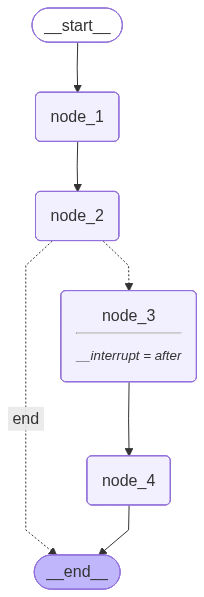

In [50]:
langgraph_app